<a href="https://colab.research.google.com/github/Aditya0204-prasad/Freemium-Gaming-Analysis/blob/main/Freemium_Gaming_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df=pd.read_csv("/content/drive/MyDrive/mobile_game_purchases.csv")

In [ ]:
#Display the first rows
df.head()

,UserID,Age,Gender,Country,Device,GameGenre,SessionCount,AverageSessionLength,SpendingSegment,InAppPurchaseAmount,FirstPurchaseDaysAfterInstall,PaymentMethod,LastPurchaseDate
0,c9889ab0-9cfc-4a75-acd9-5eab1df0015c,49.0,Male,Norway,Android,Battle Royale,9,12.83,Minnow,11.40,28.0,Apple Pay,2025-03-19
1,7c9e413c-ecca-45f2-a780-2826a07952a2,15.0,Male,Switzerland,iOS,Action RPG,11,19.39,Minnow,6.37,18.0,Debit Card,2025-06-08
2,fd61e419-1a92-4f43-a8c7-135842ad328a,23.0,Male,China,Android,Fighting,9,8.87,Minnow,15.81,30.0,Apple Pay,2025-06-02
3,bdb7f6d1-ff9a-468c-afe7-43f32a94293e,31.0,Male,Mexico,Android,Racing,12,19.56,Minnow,13.49,9.0,Debit Card,2025-04-01
4,aa7eec14-4846-47b9-b879-9c98038cda04,37.0,Female,India,Android,Battle Royale,10,15.23,Minnow,10.86,15.0,Paypal,2025-05-05


**bold text**

In [ ]:
#Check the Shape
df.shape

(3024, 13)

In [ ]:
#Check the column names
df.columns

Index(['UserID', 'Age', 'Gender', 'Country', 'Device', 'GameGenre',
       'SessionCount', 'AverageSessionLength', 'SpendingSegment',
       'InAppPurchaseAmount', 'FirstPurchaseDaysAfterInstall', 'PaymentMethod',
       'LastPurchaseDate'],
      dtype='object')

In [ ]:
#Check dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3024 entries, 0 to 3023
Data columns (total 13 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   UserID                         3024 non-null   object 
 1   Age                            2964 non-null   float64
 2   Gender                         2964 non-null   object 
 3   Country                        2964 non-null   object 
 4   Device                         2964 non-null   object 
 5   GameGenre                      2964 non-null   object 
 6   SessionCount                   3024 non-null   int64  
 7   AverageSessionLength           3024 non-null   float64
 8   SpendingSegment                3024 non-null   object 
 9   InAppPurchaseAmount            2888 non-null   float64
 10  FirstPurchaseDaysAfterInstall  2888 non-null   float64
 11  PaymentMethod                  2888 non-null   object 
 12  LastPurchaseDate               2888 non-null   o

In [ ]:
#Generate summary statistics
df.describe()

,Age,SessionCount,AverageSessionLength,InAppPurchaseAmount,FirstPurchaseDaysAfterInstall
count,2964.000000,3024.000000,3024.000000,2888.000000,2888.000000
mean,33.533738,10.074735,20.073978,102.582864,15.384003
std,11.992258,3.115863,8.585208,454.339708,8.946191
min,13.000000,1.000000,5.010000,0.000000,0.000000
25%,23.000000,8.000000,12.680000,5.987500,8.000000
50%,33.000000,10.000000,20.315000,11.975000,16.000000
75%,44.000000,12.000000,27.420000,17.762500,23.000000
max,54.000000,22.000000,34.990000,4964.450000,30.000000


In [ ]:
#for categorical column
df.describe(include='object')

,UserID,Gender,Country,Device,GameGenre,SpendingSegment,PaymentMethod,LastPurchaseDate
count,3024,2964,2964,2964,2964,3024,2888,2888
unique,3024,3,27,2,15,3,7,225
top,aa244cd4-8752-45d9-82b2-4a3f71c5d47b,Male,India,Android,Simulation,Minnow,Debit Card,2025-05-31
freq,1,1810,242,1738,219,2544,433,25


In [ ]:
#Checking missing values
df.isnull().sum()

,0
UserID,0
Age,60
Gender,60
Country,60
Device,60
GameGenre,60
SessionCount,0
AverageSessionLength,0
SpendingSegment,0
InAppPurchaseAmount,136


In [ ]:
#also calulate the percentage of missing values
(df.isnull().sum()/len(df))*100

,0
UserID,0.000000
Age,1.984127
Gender,1.984127
Country,1.984127
Device,1.984127
GameGenre,1.984127
SessionCount,0.000000
AverageSessionLength,0.000000
SpendingSegment,0.000000
InAppPurchaseAmount,4.497354


In [ ]:
#Check duplicate rows
df.duplicated().sum()

np.int64(0)

In [ ]:
#Check unique values
for col in df.columns:
  print(f"{col}:{df[col].nunique()}")

UserID:3024
Age:42
Gender:3
Country:27
Device:2
GameGenre:15
SessionCount:21
AverageSessionLength:1915
SpendingSegment:3
InAppPurchaseAmount:1839
FirstPurchaseDaysAfterInstall:31
PaymentMethod:7
LastPurchaseDate:225


In [ ]:
#inspect categorical values
for col in df.select_dtypes(include='object').columns:
  print(f"\n{col}")
  print(df[col].value_counts())


UserID
UserID
aa244cd4-8752-45d9-82b2-4a3f71c5d47b    1
7b8c4dfe-51b5-4838-b6d9-f4487bdc39d7    1
c9a0307c-947f-42e1-89b4-b78251bebe91    1
30926f5d-5869-4e9c-a180-f35ca6d98465    1
72cbbb34-7ea6-48cf-8c98-f185b5878ba3    1
                                       ..
aa7eec14-4846-47b9-b879-9c98038cda04    1
bdb7f6d1-ff9a-468c-afe7-43f32a94293e    1
fd61e419-1a92-4f43-a8c7-135842ad328a    1
7c9e413c-ecca-45f2-a780-2826a07952a2    1
c9889ab0-9cfc-4a75-acd9-5eab1df0015c    1
Name: count, Length: 3024, dtype: int64

Gender
Gender
Male      1810
Female    1098
Other       56
Name: count, dtype: int64

Country
Country
India           242
Switzerland     119
Saudi Arabia    116
Mexico          115
Netherlands     114
Germany         114
Australia       113
Japan           112
Italy           112
UK              108
Norway          107
USA             107
Sweden          106
Denmark         106
Iran            105
Brazil          105
Canada          105
South Korea     103
China           101


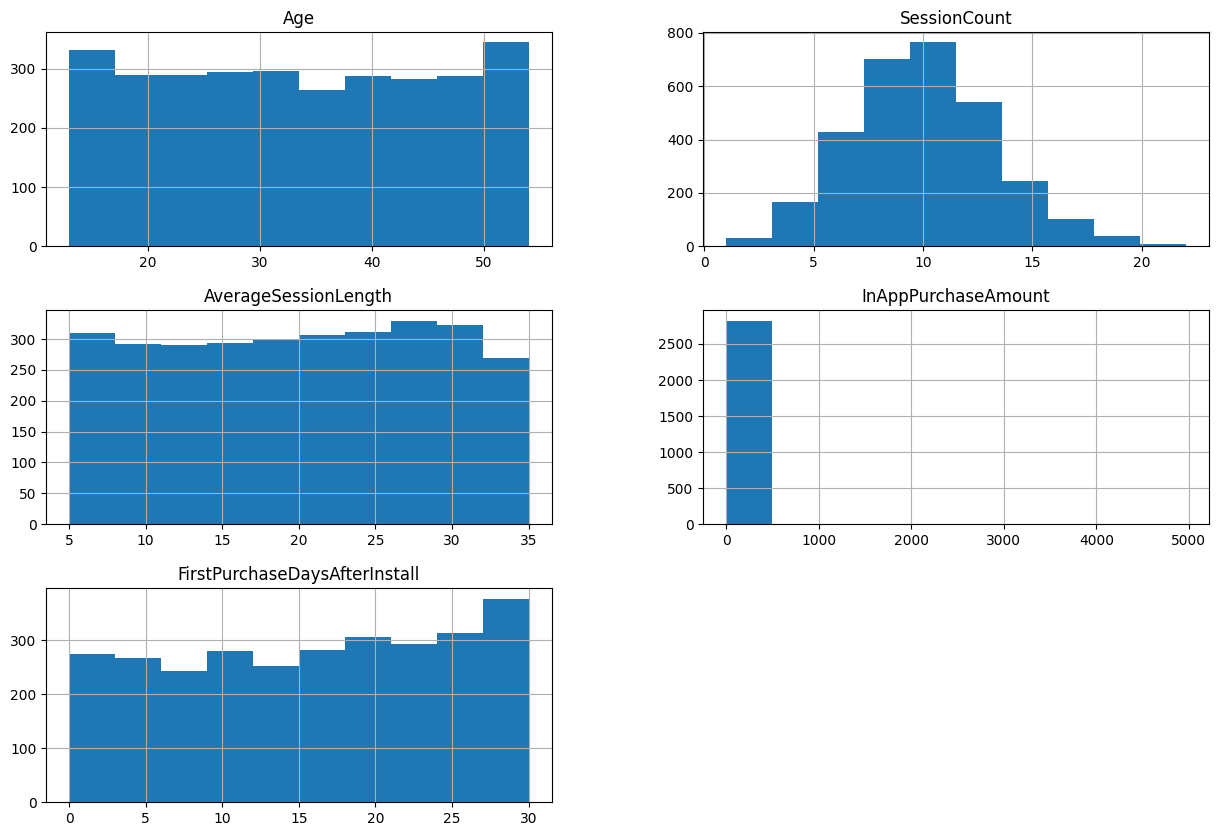

In [ ]:
#check numeric distribution
df.hist(figsize=(15,10))
plt.show()

In [ ]:
#Save the cleaned dataset
df.to_csv("cleaned_mobile_game_purchases.csv",index=False)

**Data Understanding and Exploratory Data Analysis**

In [ ]:
#Check Data Types
df.dtypes

,0
UserID,object
Age,float64
Gender,object
Country,object
Device,object
GameGenre,object
SessionCount,int64
AverageSessionLength,float64
SpendingSegment,object
InAppPurchaseAmount,float64


In [ ]:
#seprate Numerical and categorical columns
numerical_cols=df.select_dtypes(include=['int64','float64']).columns
categorical_cols=df.select_dtypes(include=['object']).columns
print("Numerical Columns:")
print(numerical_cols)
print("\nCategorical Columns:")
print(categorical_cols)

Numerical Columns:
Index(['Age', 'SessionCount', 'AverageSessionLength', 'InAppPurchaseAmount',
       'FirstPurchaseDaysAfterInstall'],
      dtype='object')

Categorical Columns:
Index(['UserID', 'Gender', 'Country', 'Device', 'GameGenre', 'SpendingSegment',
       'PaymentMethod', 'LastPurchaseDate'],
      dtype='object')


**Summary Statistics**

In [ ]:
#Numerical features
df[numerical_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,2964.0,33.533738,11.992258,13.00,23.0000,33.000,44.0000,54.00
SessionCount,3024.0,10.074735,3.115863,1.00,8.0000,10.000,12.0000,22.00
AverageSessionLength,3024.0,20.073978,8.585208,5.01,12.6800,20.315,27.4200,34.99
InAppPurchaseAmount,2888.0,102.582864,454.339708,0.00,5.9875,11.975,17.7625,4964.45
FirstPurchaseDaysAfterInstall,2888.0,15.384003,8.946191,0.00,8.0000,16.000,23.0000,30.00


In [ ]:
#Categorical Features
for col in categorical_cols:
  print(f"\n{col}")
  print(df[col].value_counts())


UserID
UserID
aa244cd4-8752-45d9-82b2-4a3f71c5d47b    1
7b8c4dfe-51b5-4838-b6d9-f4487bdc39d7    1
c9a0307c-947f-42e1-89b4-b78251bebe91    1
30926f5d-5869-4e9c-a180-f35ca6d98465    1
72cbbb34-7ea6-48cf-8c98-f185b5878ba3    1
                                       ..
aa7eec14-4846-47b9-b879-9c98038cda04    1
bdb7f6d1-ff9a-468c-afe7-43f32a94293e    1
fd61e419-1a92-4f43-a8c7-135842ad328a    1
7c9e413c-ecca-45f2-a780-2826a07952a2    1
c9889ab0-9cfc-4a75-acd9-5eab1df0015c    1
Name: count, Length: 3024, dtype: int64

Gender
Gender
Male      1810
Female    1098
Other       56
Name: count, dtype: int64

Country
Country
India           242
Switzerland     119
Saudi Arabia    116
Mexico          115
Netherlands     114
Germany         114
Australia       113
Japan           112
Italy           112
UK              108
Norway          107
USA             107
Sweden          106
Denmark         106
Iran            105
Brazil          105
Canada          105
South Korea     103
China           101


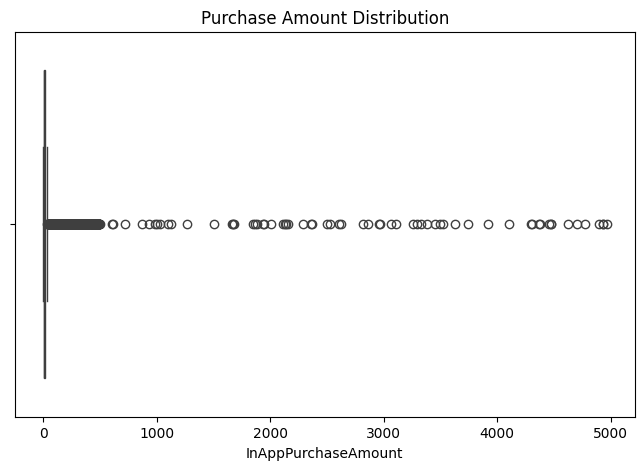

In [ ]:
#Check for Outliner
plt.figure(figsize=(8,5))
sns.boxplot(x=df['InAppPurchaseAmount'])
plt.title("Purchase Amount Distribution")
plt.show()

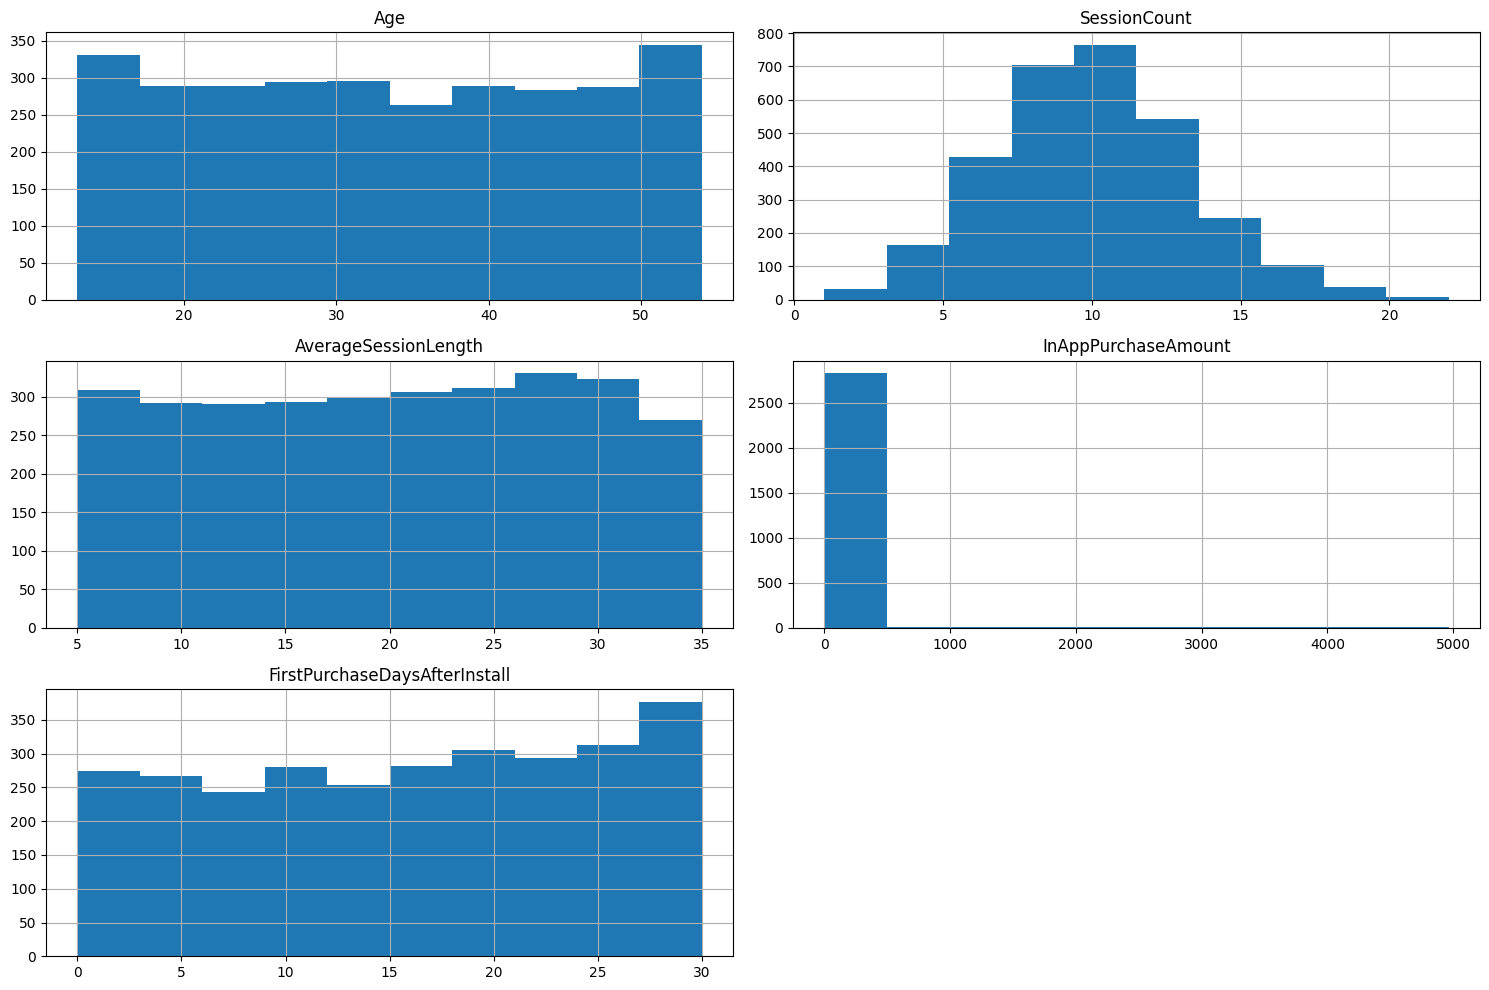

In [ ]:
#Distribution of Numerical Variables
df[numerical_cols].hist(figsize=(15,10))
plt.tight_layout()
plt.show()

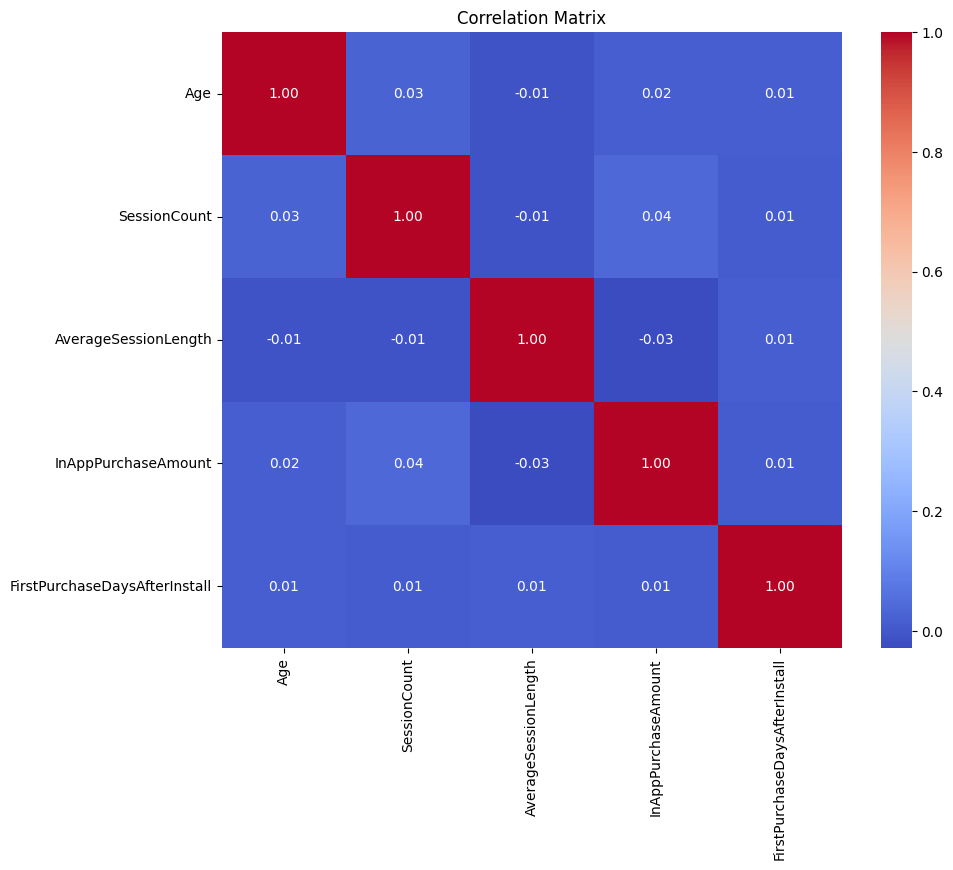

In [ ]:
#Correlation Matrix
plt.figure(figsize=(10,8))
corr=df[numerical_cols].corr()
sns.heatmap(corr,annot=True,cmap='coolwarm',fmt='.2f')
plt.title("Correlation Matrix")
plt.show()

**Analyze Player Dmographics**

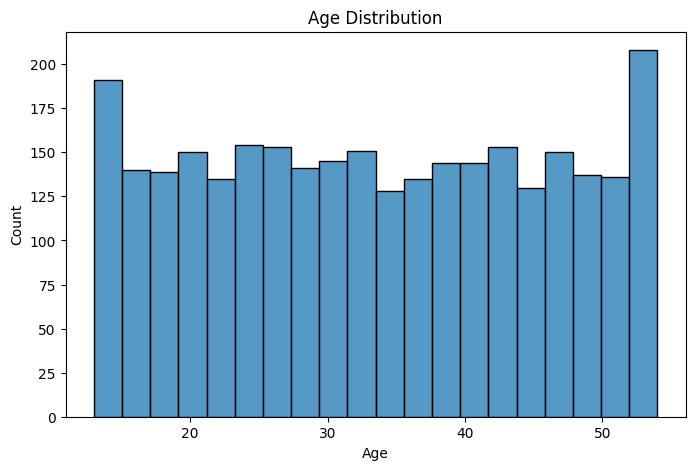

In [ ]:
#Age distribution
plt.figure(figsize=(8,5))
sns.histplot(df['Age'],bins=20)
plt.title("Age Distribution")
plt.show()

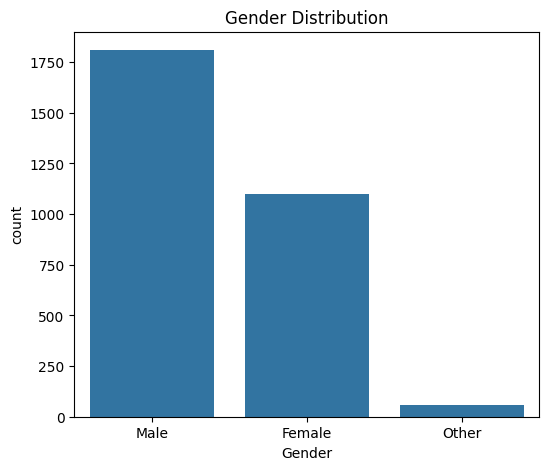

In [ ]:
#Gender Distribution
plt.figure(figsize=(6,5))
sns.countplot(x='Gender',data=df)
plt.title("Gender Distribution")
plt.show()

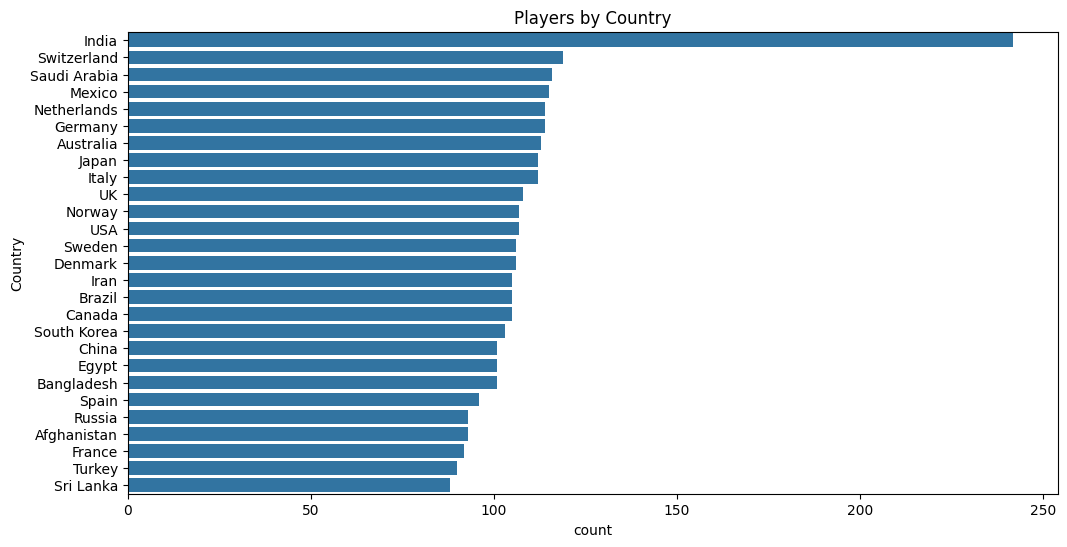

In [ ]:
#Country Distribution
plt.figure(figsize=(12,6))
sns.countplot(y='Country',data=df,order=df['Country'].value_counts().index)
plt.title("Players by Country")
plt.show()

**Device Analysis**

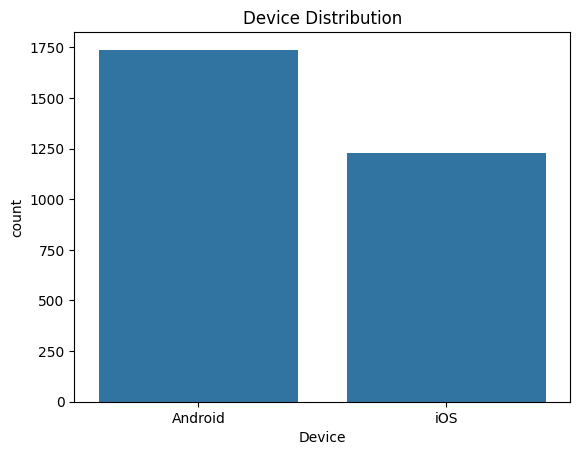

In [ ]:
sns.countplot(x='Device',data=df)
plt.title("Device Distribution")
plt.show()

In [ ]:
#Average puchase Analysis
df.groupby('Device')['InAppPurchaseAmount'].mean().sort_values()

,InAppPurchaseAmount
Device,
Android,94.670834
iOS,111.052847


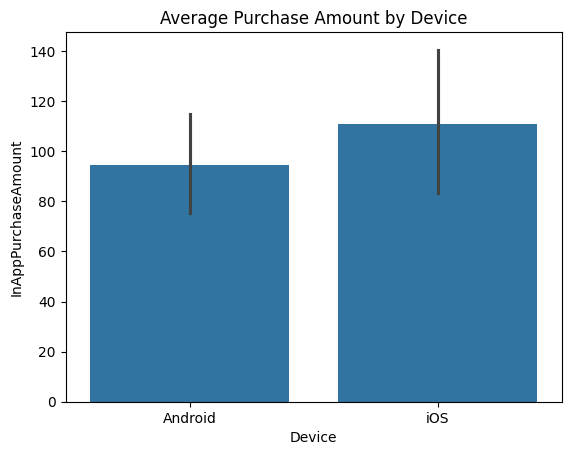

In [ ]:
#visualization
sns.barplot(x='Device',y='InAppPurchaseAmount',data=df)
plt.title("Average Purchase Amount by Device")
plt.show()

**Game Genre Analysis**

In [ ]:
#Revenue by genre
genre_revenue=df.groupby('GameGenre')['InAppPurchaseAmount'].sum()
genre_revenue.sort_values()

,InAppPurchaseAmount
GameGenre,
Action RPG,11587.56
Sandbox,14135.95
Puzzle,14297.91
Adventure,15712.46
Casual,15783.34
Sports,16167.90
Card,16392.15
Role Playing,17030.56
Simulation,17804.21


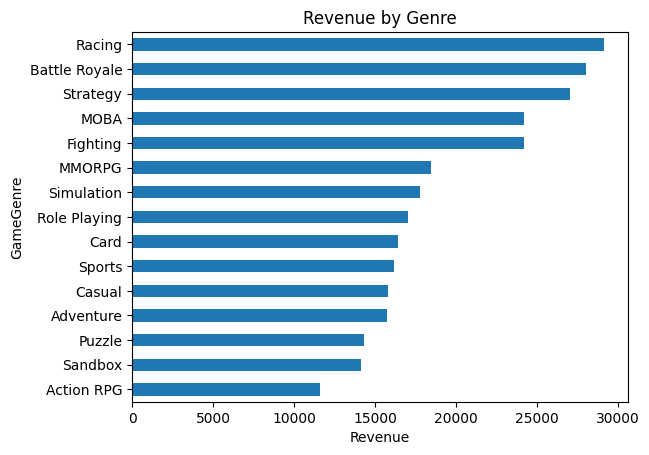

In [ ]:
#Plot
genre_revenue.sort_values().plot(kind='barh')
plt.title("Revenue by Genre")
plt.xlabel("Revenue")
plt.show()

**Spending SegmentAnalysis**

In [ ]:
#Player in each segment
df['SpendingSegment'].value_counts()

,count
SpendingSegment,
Minnow,2544
Dolphin,412
Whale,68


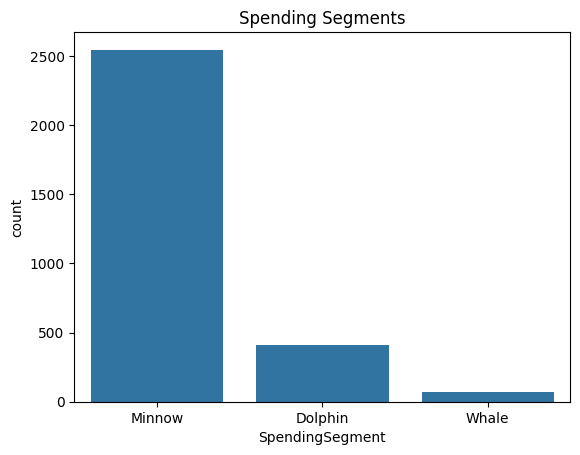

In [ ]:
#Visualization
sns.countplot(x='SpendingSegment',data=df)
plt.title("Spending Segments")
plt.show()

In [ ]:
#Revenue contribution
df.groupby('SpendingSegment')['InAppPurchaseAmount'].sum()

,InAppPurchaseAmount
SpendingSegment,
Dolphin,96288.80
Minnow,24387.37
Whale,175583.14


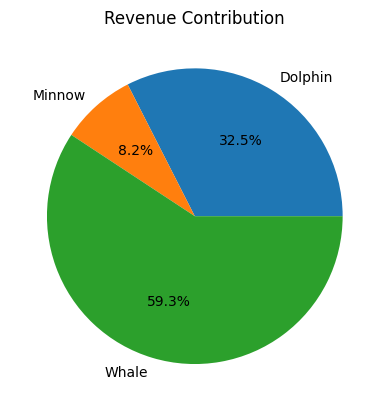

In [ ]:
#Pie chart
df.groupby('SpendingSegment')['InAppPurchaseAmount'].sum().plot(kind='pie',autopct='%1.1f%%')
plt.title("Revenue Contribution")
plt.ylabel("")
plt.show()

**Payment Method Analysis**

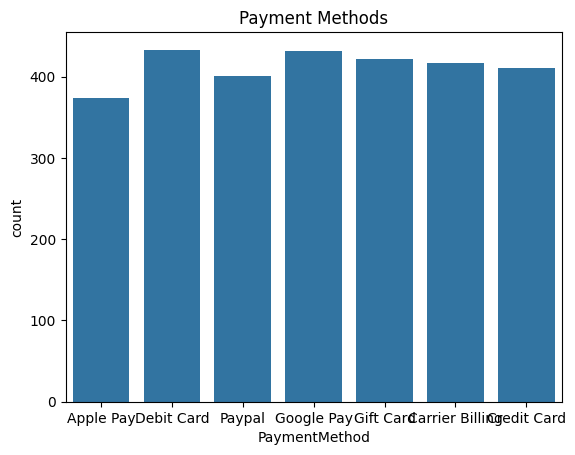

In [ ]:
sns.countplot(x='PaymentMethod',data=df)
plt.title("Payment Methods")
plt.show()

In [ ]:
#Revenue
df.groupby('PaymentMethod')['InAppPurchaseAmount'].sum()

,InAppPurchaseAmount
PaymentMethod,
Apple Pay,30628.40
Carrier Billing,41372.88
Credit Card,37564.63
Debit Card,55909.54
Gift Card,43928.45
Google Pay,38505.91
Paypal,48349.50


**Session Analysis**

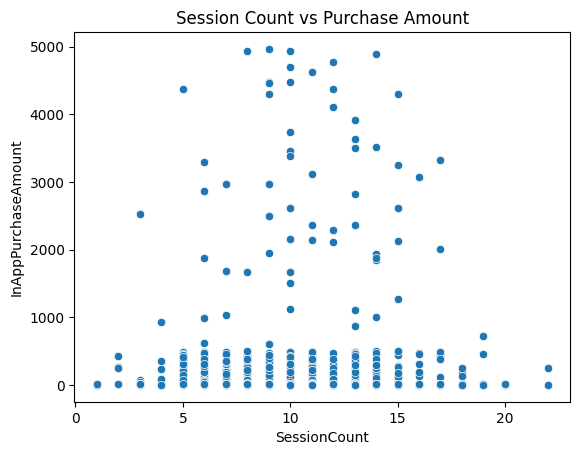

In [ ]:
#Scatter Plot
sns.scatterplot(x='SessionCount',y='InAppPurchaseAmount',data=df)
plt.title("Session Count vs Purchase Amount")
plt.show()

**Session Length Analysis**

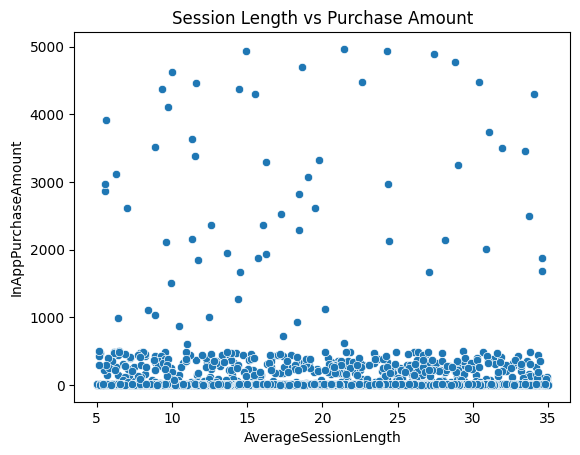

In [ ]:
sns.scatterplot(x='AverageSessionLength',y='InAppPurchaseAmount',data=df)
plt.title("Session Length vs Purchase Amount")
plt.show()

**Purchase Timing**

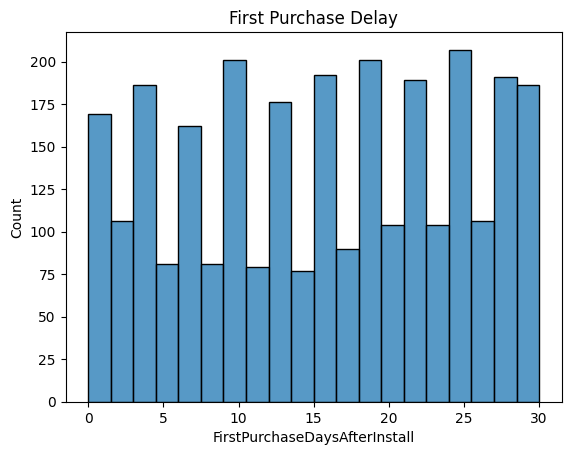

In [ ]:
sns.histplot(df['FirstPurchaseDaysAfterInstall'],bins=20)
plt.title("First Purchase Delay")
plt.show()

In [ ]:
print(df.columns.tolist())

['UserID', 'Age', 'Gender', 'Country', 'Device', 'GameGenre', 'SessionCount', 'AverageSessionLength', 'SpendingSegment', 'InAppPurchaseAmount', 'FirstPurchaseDaysAfterInstall', 'PaymentMethod', 'LastPurchaseDate']


**Increase lable padding**

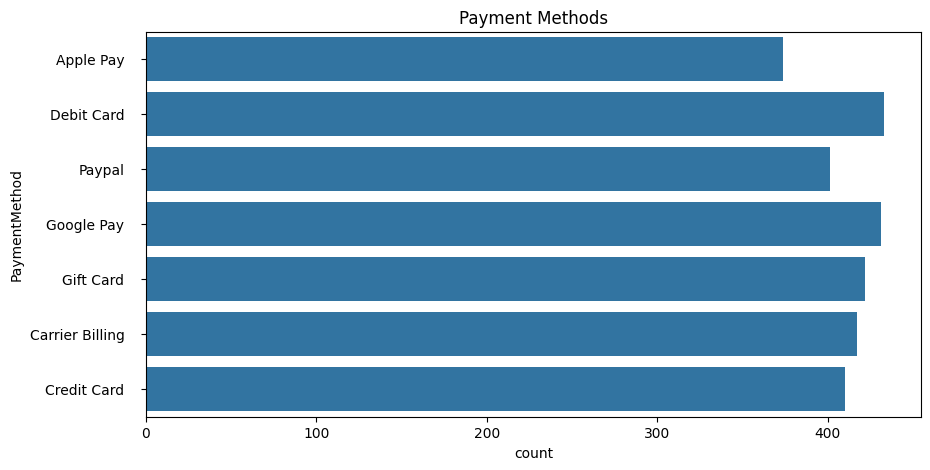

In [ ]:
plt.figure(figsize=(10,5))
ax=sns.countplot(y='PaymentMethod',data=df)
ax.tick_params(axis='y',pad=12)
ax.set_title("Payment Methods")
plt.show()

**Feature Engineering**

In [ ]:
#Days Since Last Purchase

In [ ]:
df['LastPurchaseDate']=pd.to_datetime(df['LastPurchaseDate'])
df['DaysSinceLastPurchase']=(pd.to_datetime('today')-df['LastPurchaseDate']).dt.days

In [ ]:
#Create Purchase Speed
df['PurchaseSpeed']=np.where(
    df['FirstPurchaseDaysAfterInstall']<=7,'First','slow'
          )

In [ ]:
df['PurchaseSpeed'].value_counts()

,count
PurchaseSpeed,
slow,2320
First,704


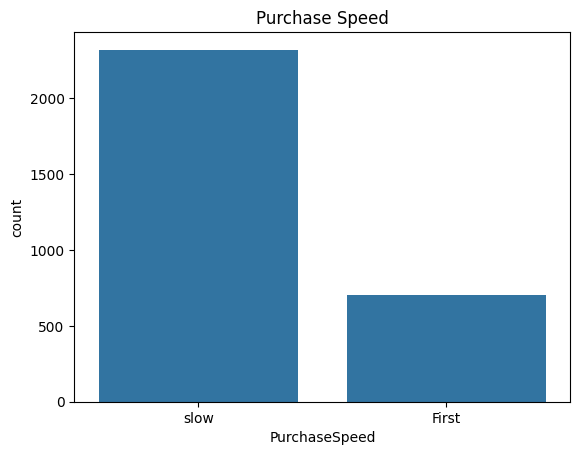

In [ ]:
#visualize
sns.countplot(x='PurchaseSpeed',data=df)
plt.title("Purchase Speed")
plt.show()

**Create Age Groups**

In [ ]:
bins=[0,18,25,35,45,100]
labels=[
    'Teen','Young Adult','Adult','Middle Age','Senior'
]
df['AgeGroup']=pd.cut(df['Age'],bins=bins,labels=labels)

In [ ]:
df['AgeGroup'].value_counts()

,count
AgeGroup,
Adult,718
Middle Age,706
Senior,631
Young Adult,509
Teen,400


**Create Session Categories**

In [ ]:
df['SessionCategory']=pd.cut(df['SessionCount'],bins=[0,20,50,100,500],labels=['Low','Medium','High','Very High'])

In [ ]:
df['SessionCategory'].value_counts()


,count
SessionCategory,
Low,3021
Medium,3
High,0
Very High,0


**Create Session length Categories**

In [ ]:
df['SessionLengthCategory']=pd.cut(df['AverageSessionLength'],bins=[0,10,20,40,100],labels=['Short','Medium','Long','Very Long'])

**Revenue Contribution by Segment**

In [ ]:
df.groupby('SpendingSegment')['InAppPurchaseAmount'].sum()

,InAppPurchaseAmount
SpendingSegment,
Dolphin,96288.80
Minnow,24387.37
Whale,175583.14


In [ ]:
#Percentage
revenue=df.groupby('SpendingSegment')['InAppPurchaseAmount'].sum()
revenue_percent=revenue/revenue.sum()*100

**Top Spending Countries**

In [ ]:
country_revenue=(df.groupby('Country')['InAppPurchaseAmount'].sum().sort_values(ascending=False))
country_revenue.head(10)

,InAppPurchaseAmount
Country,
India,34204.13
Afghanistan,20706.07
Bangladesh,17087.77
Canada,14358.44
South Korea,14115.99
Denmark,13901.79
Germany,13555.49
Italy,13549.10
Russia,12967.70


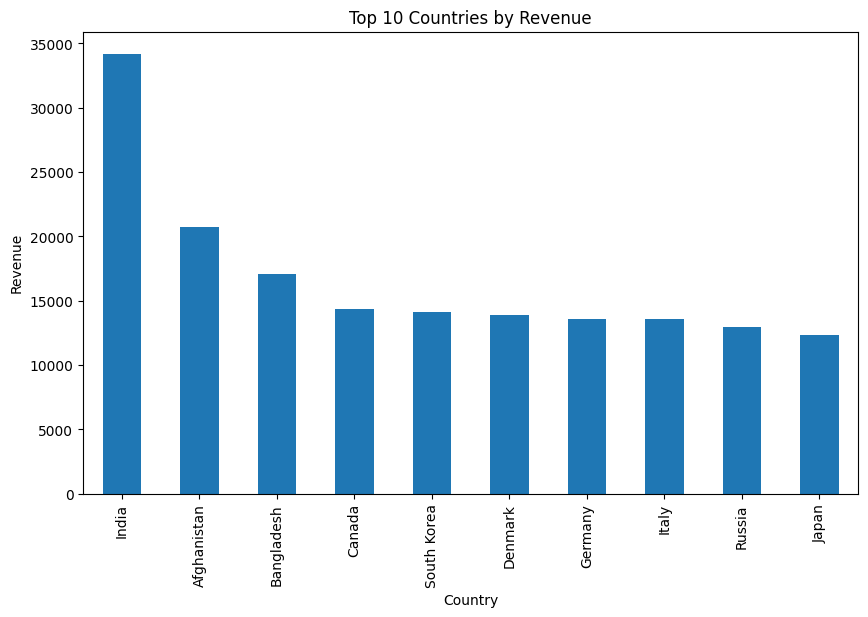

In [ ]:
#Plot
plt.figure(figsize=(10,6))
country_revenue.head(10).plot(kind='bar')
plt.title("Top 10 Countries by Revenue")
plt.ylabel("Revenue")
plt.show()

**Average Revenue by Genre**

In [ ]:
genre_avg=(df.groupby('GameGenre')['InAppPurchaseAmount'].mean().sort_values(ascending=False))

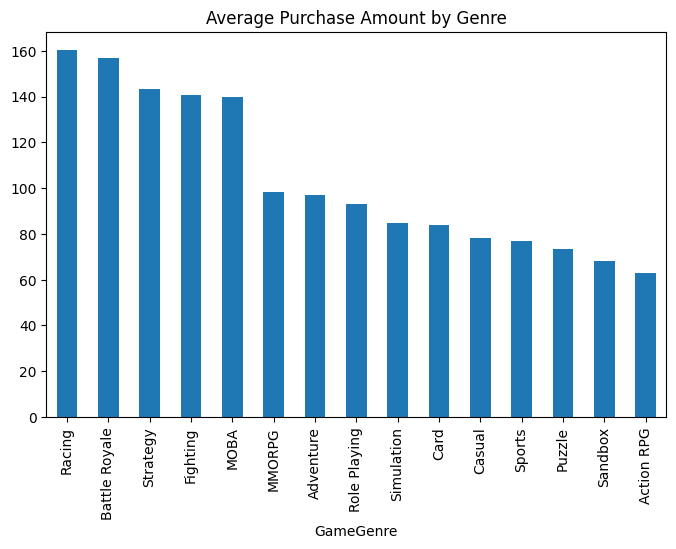

In [ ]:
#Visualization
plt.figure(figsize=(8,5))
genre_avg.plot(kind='bar')
plt.title("Average Purchase Amount by Genre")
plt.show()

**Average Revenue by Device**

In [ ]:
df.groupby('Device')['InAppPurchaseAmount'].agg(['count','mean','sum'])

,count,mean,sum
Device,,,
Android,1666,94.670834,157721.61
iOS,1166,111.052847,129487.62


**Cross Analysis**

In [ ]:
#Device*Spending Sengment
pd.crosstab(df['Gender'],df['SpendingSegment'])

SpendingSegment,Dolphin,Minnow,Whale
Gender,,,
Female,145,935,18
Male,253,1508,49
Other,8,48,0


In [ ]:
#Country*Spending Segment
pd.crosstab(df['Country'],df['SpendingSegment'])

SpendingSegment,Dolphin,Minnow,Whale
Country,,,
Afghanistan,18,71,4
Australia,12,101,0
Bangladesh,21,76,4
Brazil,15,89,1
Canada,11,90,4
China,11,88,2
Denmark,12,91,3
Egypt,15,85,1
France,12,79,1


In [ ]:
#Genre*Spending Segment
pd.crosstab(df['GameGenre'],df['SpendingSegment'])

SpendingSegment,Dolphin,Minnow,Whale
GameGenre,,,
Action RPG,24,163,4
Adventure,39,130,1
Battle Royale,25,157,7
Card,20,179,3
Casual,24,179,6
Fighting,33,144,4
MMORPG,29,166,3
MOBA,23,153,5
Puzzle,21,181,4


**Save the Enhanced DataSet**

In [ ]:
df.to_csv("mobile_game_feature_engineered.csv",index=False)

**Business KPI Analysis**

**Total Player**

In [ ]:
total_players=len(df)
print("Total Players:",total_players)

Total Players: 3024


**Total Revenue**

In [ ]:
total_revenue=df['InAppPurchaseAmount'].sum()
print(f"Toatl Revenue:${total_revenue:,.2f}")

Toatl Revenue:$296,259.31


**Average Revenue Per User**

In [ ]:
arpu=total_revenue/total_players
print(f"ARPU:${arpu:,.2f}")

ARPU:$97.97


**Average Purchase Amount**

In [ ]:
avg_purchase=df['InAppPurchaseAmount'].mean()
print(f"Average Purchase Amount:${avg_purchase:,.2f}")


Average Purchase Amount:$102.58


**Median Purchase Amount**

In [ ]:
median_purchase=df['InAppPurchaseAmount'].median()
print(f"Median Purchase Amount:${median_purchase:,.2f}")

Median Purchase Amount:$11.98


**Highest Single Purchase**

In [ ]:
highest_purchase=df['InAppPurchaseAmount'].max()
print(f"Highest Purchase:${highest_purchase:.2f}")

Highest Purchase:$4964.45


**Revenue by Country**

In [ ]:
country_revenue=(df.groupby('Country')['InAppPurchaseAmount'].sum().sort_values(ascending=False))
country_revenue

,InAppPurchaseAmount
Country,
India,34204.13
Afghanistan,20706.07
Bangladesh,17087.77
Canada,14358.44
South Korea,14115.99
Denmark,13901.79
Germany,13555.49
Italy,13549.10
Russia,12967.70


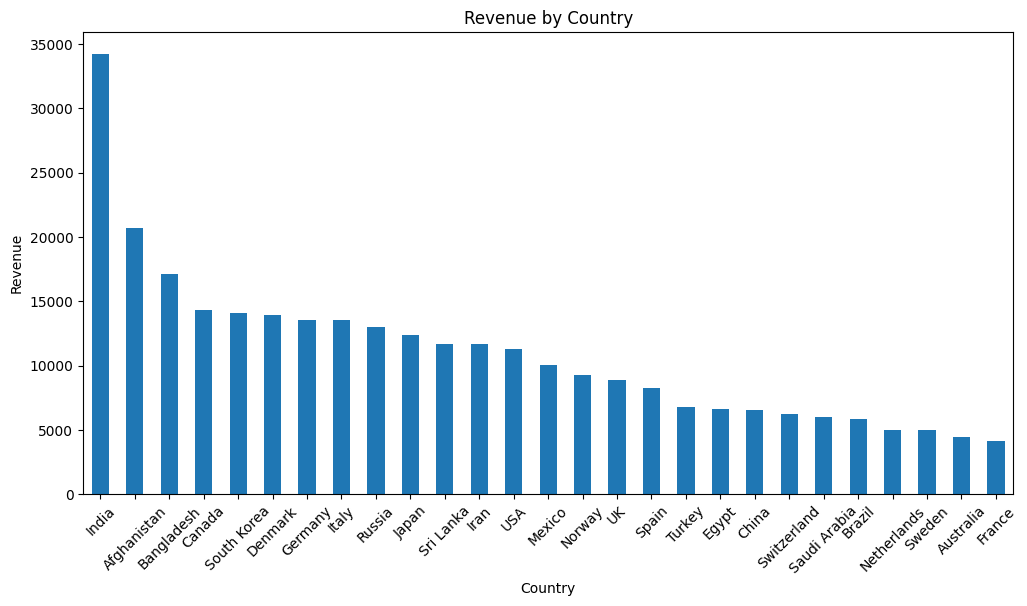

In [ ]:
#visualization
plt.figure(figsize=(12,6))
country_revenue.plot(kind='bar')
plt.title("Revenue by Country")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

**Revenue by Game Genre**

In [ ]:
genre_revenue=(df.groupby('GameGenre')['InAppPurchaseAmount'].sum().sort_values(ascending=False))
genre_revenue

,InAppPurchaseAmount
GameGenre,
Racing,29163.56
Battle Royale,28046.79
Strategy,27066.62
MOBA,24190.19
Fighting,24177.92
MMORPG,18444.36
Simulation,17804.21
Role Playing,17030.56
Card,16392.15


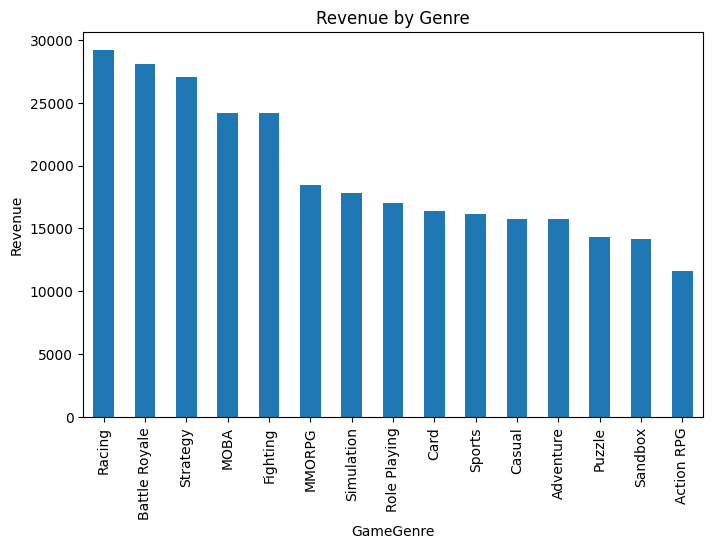

In [ ]:
#Visualization
plt.figure(figsize=(8,5))
genre_revenue.plot(kind='bar')
plt.title("Revenue by Genre")
plt.ylabel("Revenue")
plt.show()

**Revenue by Device**

In [ ]:
device_revenue=(df.groupby('Device')['InAppPurchaseAmount'].sum().sort_values(ascending=False))
device_revenue

,InAppPurchaseAmount
Device,
Android,157721.61
iOS,129487.62


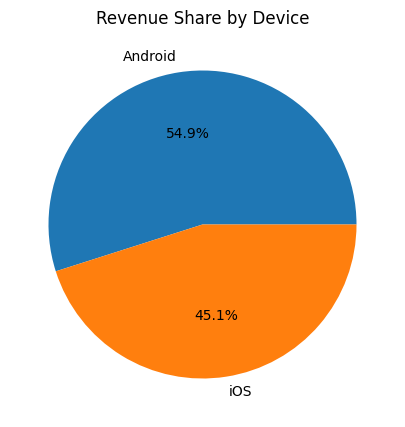

In [ ]:
#Visualization
plt.figure(figsize=(6,5))
device_revenue.plot(kind='pie',
                    autopct='%1.1f%%')

plt.ylabel("")
plt.title("Revenue Share by Device")

plt.show()

**Revenue by Spending Segment**

In [ ]:
segment_revenue=(df.groupby('SpendingSegment')['InAppPurchaseAmount'].sum().sort_values(ascending=False))
segment_revenue

,InAppPurchaseAmount
SpendingSegment,
Whale,175583.14
Dolphin,96288.80
Minnow,24387.37


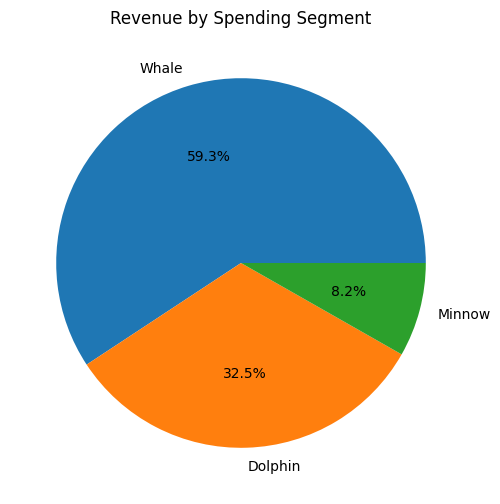

In [ ]:
#Visualization
plt.figure(figsize=(6,6))
segment_revenue.plot(kind='pie',
                    autopct='%1.1f%%')

plt.ylabel("")
plt.title("Revenue by Spending Segment")

plt.show()

**Average Revenue by Country**

In [ ]:
country_avg=(df.groupby('Country')['InAppPurchaseAmount'].mean().sort_values(ascending=False))
country_avg

,InAppPurchaseAmount
Country,
Afghanistan,227.539231
Bangladesh,172.603737
Canada,149.567083
Russia,147.360227
India,146.171496
South Korea,139.762277
Sri Lanka,137.682588
Denmark,137.641485
Italy,127.821698


**Average revenue by Genre**

In [ ]:
genre_avg=(
    df.groupby('GameGenre')['InAppPurchaseAmount'].mean().sort_values(ascending=False)
)
genre_avg

,InAppPurchaseAmount
GameGenre,
Racing,160.239341
Battle Royale,156.685978
Strategy,143.209630
Fighting,140.569302
MOBA,139.827688
MMORPG,98.108298
Adventure,96.990494
Role Playing,93.063169
Simulation,84.781952


**Top 10 Highest Spending Player**

In [ ]:
top_player=(
    df.sort_values(by='InAppPurchaseAmount',ascending=False)
)
top_player.head(10)


,UserID,Age,Gender,Country,Device,GameGenre,SessionCount,AverageSessionLength,SpendingSegment,InAppPurchaseAmount,FirstPurchaseDaysAfterInstall,PaymentMethod,LastPurchaseDate,DaysSinceLastPurchase,PurchaseSpeed,AgeGroup,SessionCategory,SessionLengthCategory
59,b5c61dc0-138d-4d49-ae4a-c4ca75787cb2,49.0,Male,Afghanistan,Android,Strategy,9,21.42,Whale,4964.45,11.0,Credit Card,2025-01-28,532.0,slow,Senior,Low,Long
2028,9ce85d56-3f8f-431a-b0bf-eec096811b39,15.0,Male,Iran,iOS,Battle Royale,8,14.91,Whale,4931.98,22.0,Paypal,2025-07-15,364.0,slow,Teen,Low,Medium
760,a8881761-c5ca-4ded-ad96-81e76b2f04e1,37.0,Male,Denmark,Android,Adventure,10,24.31,Whale,4930.28,11.0,Debit Card,2025-04-15,455.0,slow,Middle Age,Low,Long
2563,3adbf004-12bb-4abc-985a-ec2c3e399704,32.0,Male,Russia,iOS,MMORPG,14,27.42,Whale,4893.16,4.0,Debit Card,2025-04-13,457.0,First,Adult,Low,Long
2304,a9f827e9-f212-47ab-8c8a-81e6b6d7145d,47.0,Male,Afghanistan,iOS,Simulation,12,28.80,Whale,4770.77,2.0,Paypal,2025-03-07,494.0,First,Senior,Low,Long
952,69221c7c-c50f-4b3f-a67f-3c1450e4f6d8,33.0,Male,Canada,Android,MOBA,10,18.63,Whale,4700.56,2.0,Gift Card,2025-04-17,453.0,First,Adult,Low,Medium
1212,af42adc7-ff91-418f-935e-b3b2d0827a45,46.0,Male,Bangladesh,iOS,Fighting,11,9.99,Whale,4619.48,19.0,Paypal,2025-08-07,341.0,slow,Senior,Low,Short
644,56824487-498c-4c14-a94b-1bf6e680769c,30.0,Female,India,Android,Fighting,9,22.62,Whale,4475.47,0.0,Paypal,2025-04-21,449.0,First,Adult,Low,Long
2829,cb7c4c69-eda2-4c2a-a4f2-45f16a8bf100,21.0,Female,Canada,iOS,Role Playing,10,30.40,Whale,4471.87,9.0,Debit Card,2025-04-27,443.0,slow,Young Adult,Low,Long
2880,5b59b39a-26b8-40b7-941d-c07fb6eac6af,50.0,Male,Spain,Android,MOBA,9,11.59,Whale,4456.30,24.0,Carrier Billing,2025-05-05,435.0,slow,Senior,Low,Medium


**KPI Summary Table**

In [ ]:
kpi_summary=pd.DataFrame({
    "KPI":[
        "Total Players",
        "Total Revenue",
        "Average Revenue Per User",
        "Average Purchase Amount",
        "Median Purchase Amount",
        "Highest Single Purchase"
    ],
    "Value":[
        total_players,
        round(total_revenue,2),
        round(arpu,2),
        round(avg_purchase,2),
        round(median_purchase,2),
        round(highest_purchase,2)
    ]
})
kpi_summary

,KPI,Value
0,Total Players,3024.00
1,Total Revenue,296259.31
2,Average Revenue Per User,97.97
3,Average Purchase Amount,102.58
4,Median Purchase Amount,11.98
5,Highest Single Purchase,4964.45


**Advanced Business Analysis**

*Which age Group Generate the Most Revenue?*

In [ ]:
age_revenue=(df.groupby('AgeGroup')['InAppPurchaseAmount'].sum().sort_values(ascending=False))
age_revenue

/tmp/ipykernel_3001/1387347682.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_revenue=(df.groupby('AgeGroup')['InAppPurchaseAmount'].sum().sort_values(ascending=False))


,InAppPurchaseAmount
AgeGroup,
Adult,76601.69
Middle Age,74135.73
Senior,71394.23
Teen,42952.88
Young Adult,29077.74


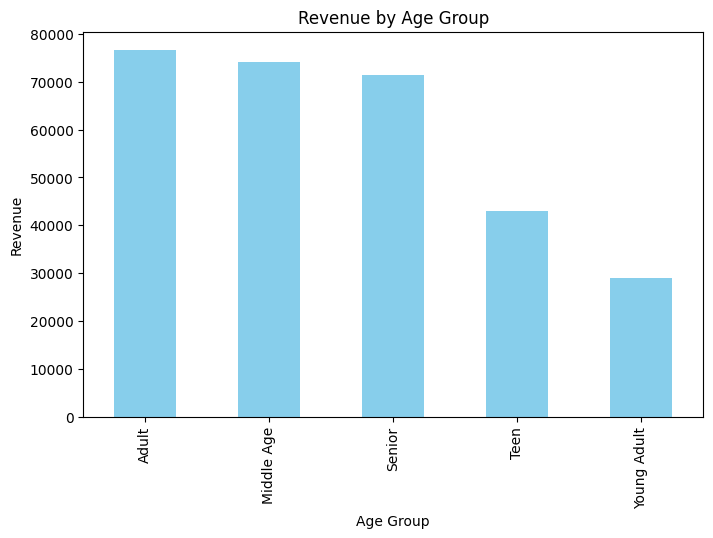

In [ ]:
#visualization
plt.figure(figsize=(8,5))
age_revenue.plot(kind='bar',color='skyblue')
plt.title("Revenue by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Revenue")
plt.show()

*Which Gender Spends More*

In [ ]:
gender_revenue=(
    df.groupby('Gender')['InAppPurchaseAmount'].sum().sort_values(ascending=False)
)
gender_revenue


,InAppPurchaseAmount
Gender,
Male,199775.13
Female,90379.23
Other,1940.05


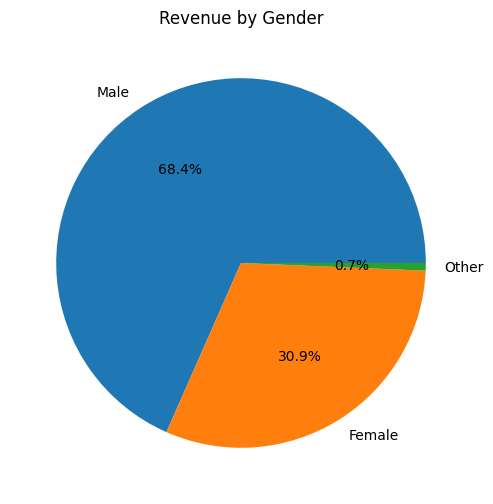

In [ ]:
#visualization
plt.figure(figsize=(6,6))
gender_revenue.plot(kind='pie',
                    autopct='%1.1f%%')

plt.ylabel("")
plt.title("Revenue by Gender")

plt.show()



**Average Purchase by spending Segement**

In [ ]:
segment_avg=(
    df.groupby('SpendingSegment')['InAppPurchaseAmount'].mean().sort_values(ascending=False)
)
segment_avg

,InAppPurchaseAmount
SpendingSegment,
Whale,2787.033968
Dolphin,245.634694
Minnow,10.023580


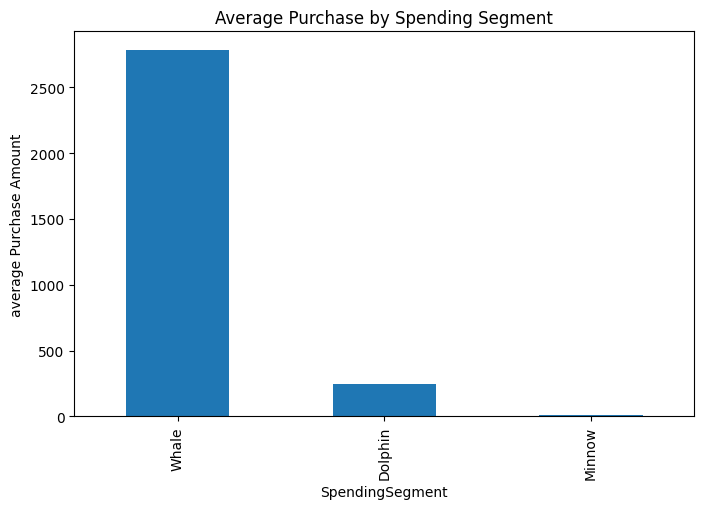

In [ ]:
#Visualization
plt.figure(figsize=(8,5))
segment_avg.plot(kind='bar'
                )

plt.ylabel("average Purchase Amount")
plt.title("Average Purchase by Spending Segment")

plt.show()

**Session Count by Spending Segment**

In [ ]:
segment_sessions=(
    df.groupby('SpendingSegment')['SessionCount'].mean()
)
segment_sessions


,SessionCount
SpendingSegment,
Dolphin,10.123786
Minnow,10.044025
Whale,10.926471


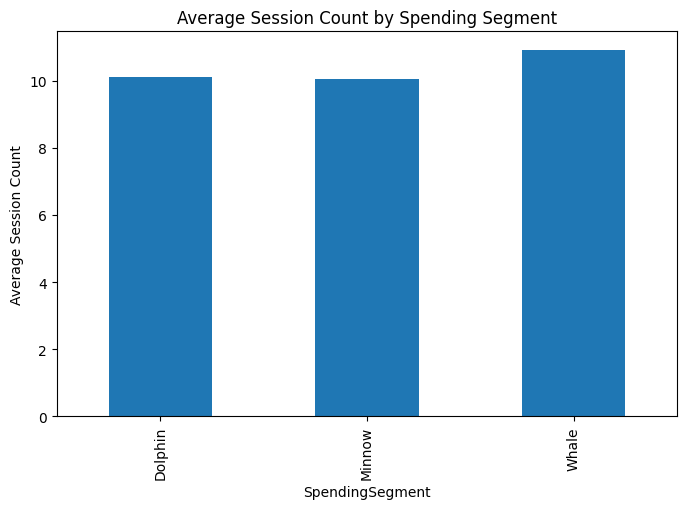

In [ ]:
#Visualization
plt.figure(figsize=(8,5))
segment_sessions.plot(kind='bar')

plt.ylabel("Average Session Count")
plt.title("Average Session Count by Spending Segment")

plt.show()

**Session length by Spending Segment**

In [ ]:
segment_length=(
    df.groupby('SpendingSegment')['AverageSessionLength'].mean()
)
segment_length


,AverageSessionLength
SpendingSegment,
Dolphin,20.035704
Minnow,20.137445
Whale,17.931471


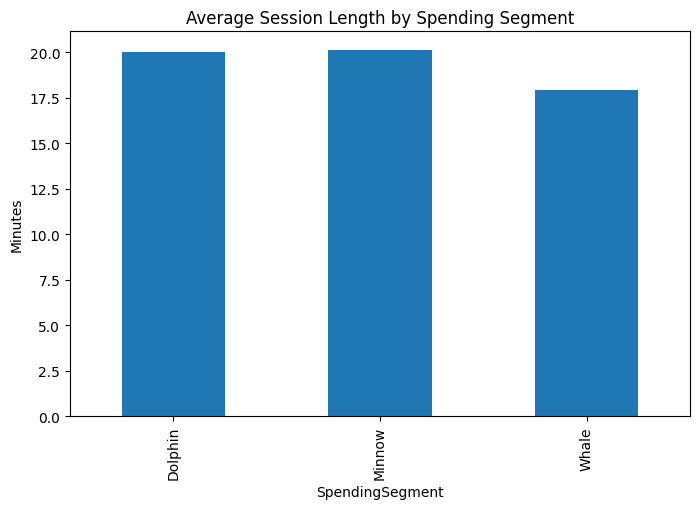

In [ ]:
#visualization
plt.figure(figsize=(8,5))
segment_length.plot(kind='bar')

plt.ylabel("Minutes")
plt.title("Average Session Length by Spending Segment")

plt.show()

**Device Preference by Spending Segment**

In [ ]:
device_segment=pd.crosstab(
    df['Device'],
    df['SpendingSegment']
)
device_segment

SpendingSegment,Dolphin,Minnow,Whale
Device,,,
Android,233,1468,37
iOS,171,1028,27


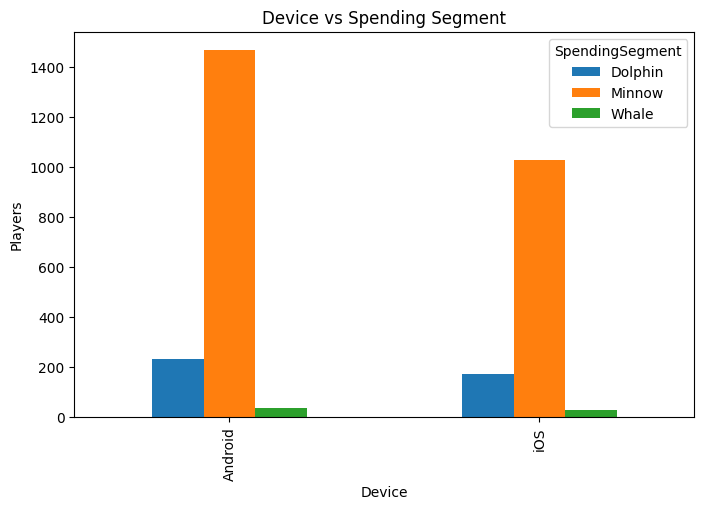

In [ ]:
#Visualization
device_segment.plot(kind='bar',
                    figsize=(8,5))
plt.title("Device vs Spending Segment")
plt.ylabel("Players")
plt.show()

**Payment Method Preference**

In [ ]:
payment_segment=pd.crosstab(
    df['PaymentMethod'],
    df['SpendingSegment']
)
payment_segment

SpendingSegment,Dolphin,Minnow,Whale
PaymentMethod,,,
Apple Pay,44,325,5
Carrier Billing,58,351,8
Credit Card,53,350,7
Debit Card,58,361,14
Gift Card,68,344,10
Google Pay,51,371,9
Paypal,60,331,10


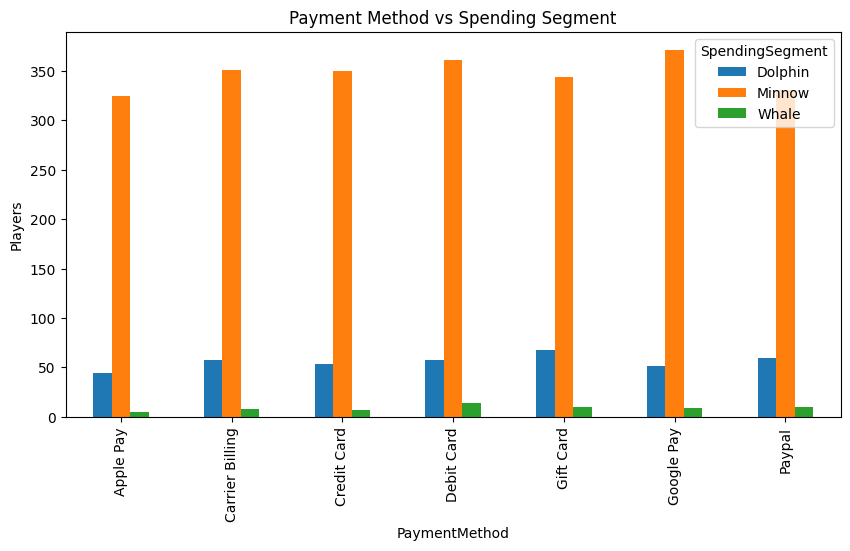

In [ ]:
#Visualization
payment_segment.plot(kind='bar',
                    figsize=(10,5))
plt.title("Payment Method vs Spending Segment")
plt.ylabel("Players")
plt.show()

**Game Genre VS Spending Segment**

In [ ]:
genre_segment=pd.crosstab(
    df['GameGenre'],
    df['SpendingSegment']
)
genre_segment

SpendingSegment,Dolphin,Minnow,Whale
GameGenre,,,
Action RPG,24,163,4
Adventure,39,130,1
Battle Royale,25,157,7
Card,20,179,3
Casual,24,179,6
Fighting,33,144,4
MMORPG,29,166,3
MOBA,23,153,5
Puzzle,21,181,4


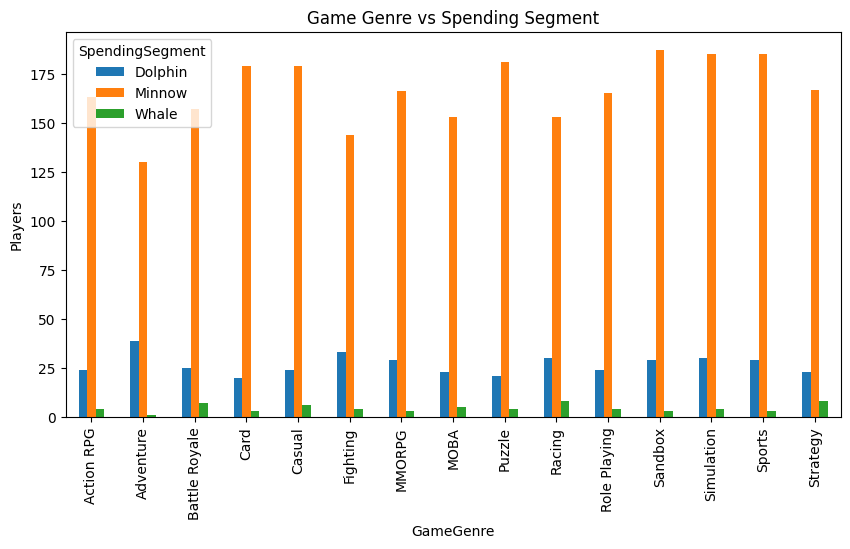

In [ ]:
#Visualization
genre_segment.plot(kind='bar',
                    figsize=(10,5))
plt.title("Game Genre vs Spending Segment")
plt.ylabel("Players")
plt.show()

**Fast Vs Slow Purchase**

In [ ]:
#Average Purchase Amount
purchase_speed=(df.groupby('PurchaseSpeed')['InAppPurchaseAmount'].mean())
purchase_speed


,InAppPurchaseAmount
PurchaseSpeed,
First,88.580185
slow,107.096548


Text(0, 0.5, 'Average Purchase')

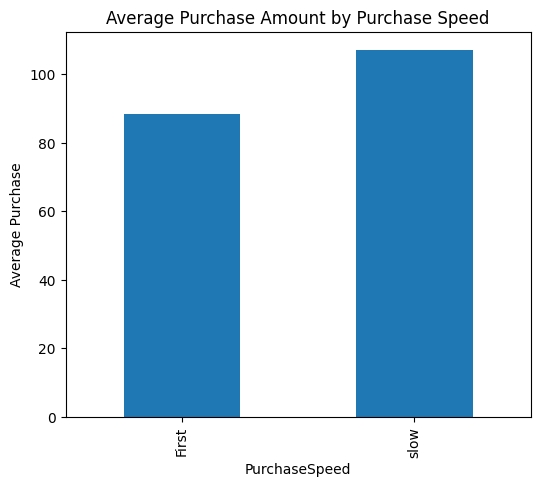

In [ ]:
#Visualization
purchase_speed.plot(
    kind='bar',
    figsize=(6,5)
)
plt.title("Average Purchase Amount by Purchase Speed")
plt.ylabel("Average Purchase")


**Top 10 Revenue Countries**

In [ ]:
top10=(df.groupby('Country')['InAppPurchaseAmount'].sum().sort_values(ascending=False).head(10)
)
top10

,InAppPurchaseAmount
Country,
India,34204.13
Afghanistan,20706.07
Bangladesh,17087.77
Canada,14358.44
South Korea,14115.99
Denmark,13901.79
Germany,13555.49
Italy,13549.10
Russia,12967.70


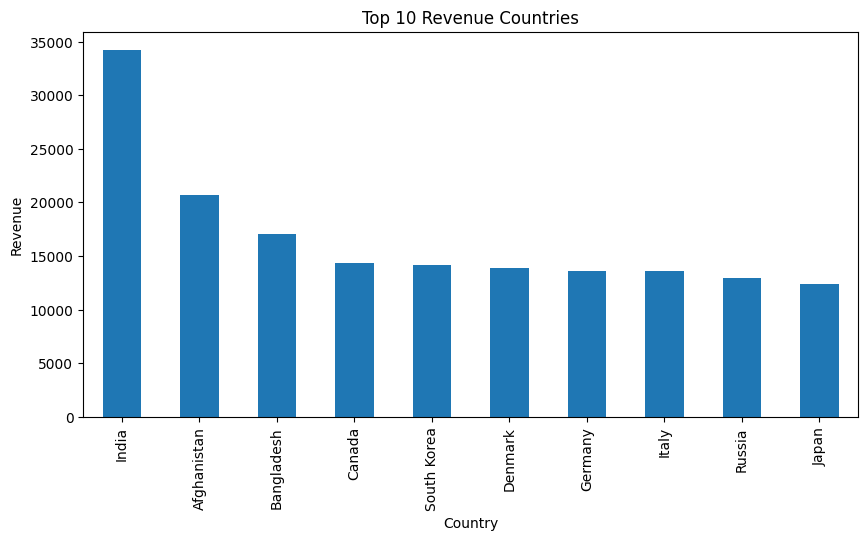

In [ ]:
#Visualization
plt.figure(figsize=(10,5))
top10.plot(kind='bar')
plt.title("Top 10 Revenue Countries")
plt.ylabel("Revenue")
plt.show()

In [ ]:
df.to_excel("Freemium_Gaming_Analysis.xlsx", index=False)